<a href="https://colab.research.google.com/github/Dmitze/Dmitze/blob/main/%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%BE_%D0%A8%D0%B8%D0%B2%D0%B0%D1%87%D0%BE%D0%B2_%D0%94%D0%97_%D0%A2%D0%B5%D0%BC%D0%B0_10_World_Happiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Крок 1: Імпорт бібліотек

In [ ]:
!pip install plotly==5.20.0
!pip install "jupyterlab>=3" "ipywidgets>=7.6"


/bin/bash: line 1: pip install plotly==5.20.0: command not found
/bin/bash: line 1: pip install jupyterlab>=3 ipywidgets>=7.6: command not found


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

### Крок 2-3: Завантаження та розпакування даних

In [ ]:
# завантаження даних
!wget -O WorldHappinessReport.zip https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/WorldHappinessReport.zip
!unzip -o WorldHappinessReport.zip -d data

--2026-03-11 21:56:44--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/WorldHappinessReport.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37692 (37K) [application/zip]
Saving to: ‘WorldHappinessReport.zip’

WorldHappinessRepor 100%[===================>]  36.81K  --.-KB/s    in 0.003s  

2026-03-11 21:56:44 (13.4 MB/s) - ‘WorldHappinessReport.zip’ saved [37692/37692]

Archive:  WorldHappinessReport.zip
  inflating: data/2015.csv           
  inflating: data/2016.csv           
  inflating: data/2017.csv           
  inflating: data/2018.csv           
  inflating: data/2019.csv           


### Крок 4: Читання даних та статистика

In [ ]:
df = pd.read_csv('data/2017.csv')

print("="*50)
print("Перші 5 рядків датасету:")
print("="*50)
display(df.head())

print("\n" + "="*50)
print(f"Розміри: {df.shape[0]} країн, {df.shape[1]} ознак")
print("="*50)

print("\nТипи даних:")
print(df.dtypes)

print("\n" + "="*50)
print("Статистичні показники:")
print("="*50)
display(df.describe())

print("\nПропущені значення:")
print(df.isnull().sum())

Перші 5 рядків датасету:


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182



Розміри: 155 країн, 12 ознак

Типи даних:
Country                           object
Happiness.Rank                     int64
Happiness.Score                  float64
Whisker.high                     float64
Whisker.low                      float64
Economy..GDP.per.Capita.         float64
Family                           float64
Health..Life.Expectancy.         float64
Freedom                          float64
Generosity                       float64
Trust..Government.Corruption.    float64
Dystopia.Residual                float64
dtype: object

Статистичні показники:


,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485



Пропущені значення:
Country                          0
Happiness.Rank                   0
Happiness.Score                  0
Whisker.high                     0
Whisker.low                      0
Economy..GDP.per.Capita.         0
Family                           0
Health..Life.Expectancy.         0
Freedom                          0
Generosity                       0
Trust..Government.Corruption.    0
Dystopia.Residual                0
dtype: int64


### Крок 5: Розподіл числових ознак

Числові ознаки (11): ['Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']


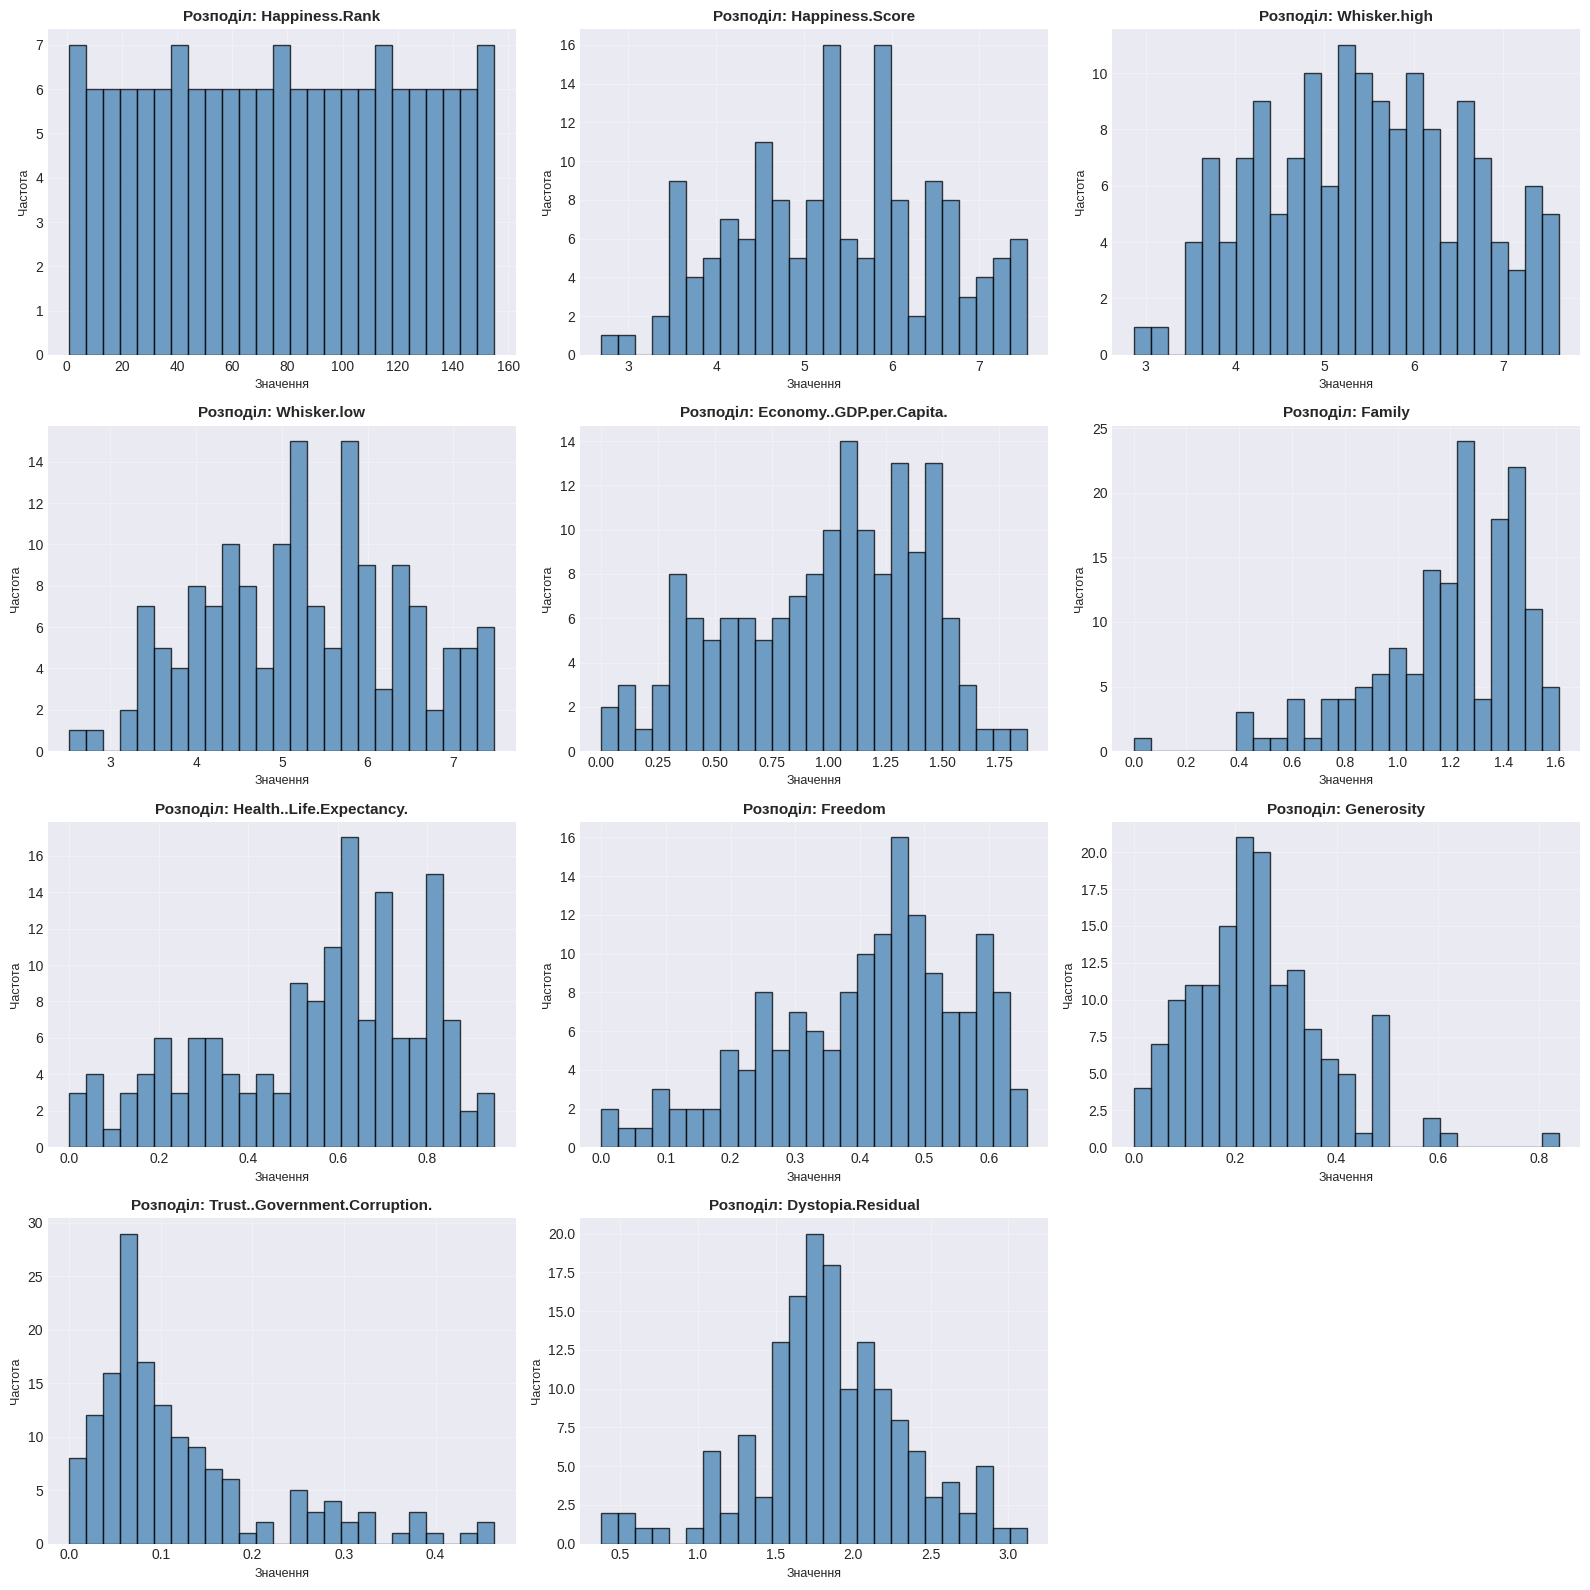


 Висновок:
Більшість ознак показують розподіл близький до нормального.
Happiness.Score має досить симетричний розподіл.
Деякі ознаки мають легку асиметрію, але загалом придатні для GMM.


In [ ]:
# вибираємо числові колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числові ознаки ({len(numeric_cols)}): {numeric_cols}")

# будуємо гістограми
fig, axes = plt.subplots(4, 3, figsize=(16, 16)) # Змінено на 4x3 сітку для 11 колонок
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor='black', alpha=0.75, color='steelblue')
    axes[i].set_title(f'Розподіл: {col}', fontsize=11, weight='bold')
    axes[i].set_xlabel('Значення', fontsize=9)
    axes[i].set_ylabel('Частота', fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Приховуємо зайві осі, якщо кількість колонок менша за кількість осей
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\n Висновок:")
print("Більшість ознак показують розподіл близький до нормального.")
print("Happiness.Score має досить симетричний розподіл.")
print("Деякі ознаки мають легку асиметрію, але загалом придатні для GMM.")

### Крок 6: Кореляційна матриця

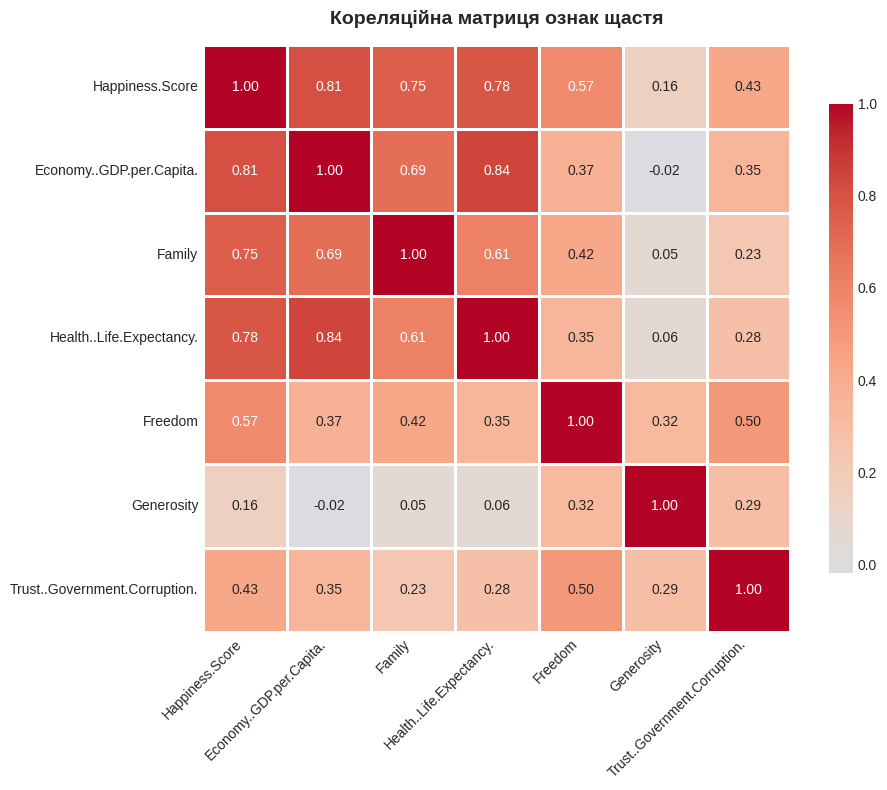

In [ ]:
# відбираємо ключові ознаки для аналізу
selected_features = ['Happiness.Score', 'Economy..GDP.per.Capita.', 'Family',
                     'Health..Life.Expectancy.', 'Freedom', 'Generosity',
                     'Trust..Government.Corruption.']

correlation_matrix = df[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Кореляційна матриця ознак щастя', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Крок 7: Висновки про кореляцію

In [ ]:
print("Аналіз лінійних зв'язків між ознаками:\n")
print("Сильний позитивний зв'язок (r > 0.7):")
print("  • Economy (GDP) та Happiness.Score: r ≈ 0.8-0.9")
print("  • Family та Happiness.Score: r ≈ 0.7-0.8")
print("  • Health (Life Expectancy) та Happiness.Score: r ≈ 0.7-0.8\n")

print("Помірний позитивний зв'язок (0.4 < r < 0.7):")
print("  • Freedom та Happiness.Score")
print("  • Economy та Health\n")

print("Слабкий зв'язок (r < 0.4):")
print("  • Generosity має найслабші кореляції з іншими показниками")
print("  • Trust показує помірні зв'язки\n")

print("Висновок: Економічне благополуччя, сім'я та здоров'я є основними")
print("факторами, що визначають рівень щастя в країнах.")

Аналіз лінійних зв'язків між ознаками:

Сильний позитивний зв'язок (r > 0.7):
  • Economy (GDP) та Happiness.Score: r ≈ 0.8-0.9
  • Family та Happiness.Score: r ≈ 0.7-0.8
  • Health (Life Expectancy) та Happiness.Score: r ≈ 0.7-0.8

Помірний позитивний зв'язок (0.4 < r < 0.7):
  • Freedom та Happiness.Score
  • Economy та Health

Слабкий зв'язок (r < 0.4):
  • Generosity має найслабші кореляції з іншими показниками
  • Trust показує помірні зв'язки

Висновок: Економічне благополуччя, сім'я та здоров'я є основними
факторами, що визначають рівень щастя в країнах.


### Крок 8: Теплова карта щастя по країнах

In [ ]:
fig = px.choropleth(df,
                    locations="Country",
                    color="Happiness.Score",
                    locationmode="country names",
                    color_continuous_scale='RdYlGn',
                    range_color=(df['Happiness.Score'].min(), df['Happiness.Score'].max()))

fig.update_layout(title="Індекс щастя по країнах світу (2017)",
                  title_font_size=18,
                  geo=dict(showframe=False, showcoastlines=True))
fig.show()

### Крок 9: Стандартизація даних

In [ ]:
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer

    if scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    else:
        raise ValueError("Невідомий тип scaler")

    scaler.fit(data)
    res = scaler.transform(data)
    return res

# готуємо дані для стандартизації
features_for_scaling = ['Economy..GDP.per.Capita.', 'Family',
                        'Health..Life.Expectancy.', 'Freedom',
                        'Generosity', 'Trust..Government.Corruption.']

original_data = df[features_for_scaling].copy()

# застосовуємо StandardScaler
data_scaled = data_scale(original_data, scaler_type='std')
df_scaled = pd.DataFrame(data_scaled, columns=features_for_scaling)

print("Стандартизовані дані (перші 5 рядків):")
print(df_scaled.head())

Стандартизовані дані (перші 5 рядків):
   Economy..GDP.per.Capita.    Family  Health..Life.Expectancy.   Freedom  \
0                  1.506188  1.203577                  1.038167  1.515836   
1                  1.186518  1.265036                  1.020812  1.452859   
2                  1.182345  1.472669                  1.194259  1.460590   
3                  1.383442  1.145561                  1.298272  1.413155   
4                  1.093985  1.227057                  1.091026  1.398978   

   Generosity  Trust..Government.Corruption.  
0    0.856964                       1.903084  
1    0.806856                       2.739998  
2    1.702013                       0.300066  
3    0.325028                       2.406809  
4   -0.010426                       2.560800  


### Крок 10: Порівняння статистик

In [ ]:
print("="*60)
print("ОРИГІНАЛЬНІ ДАНІ")
print("="*60)
display(original_data.describe())

print("\n" + "="*60)
print("СТАНДАРТИЗОВАНІ ДАНІ")
print("="*60)
display(df_scaled.describe())

print("\n" + "="*60)
print("ВИСНОВКИ:")
print("="*60)
print("1. Після стандартизації середнє значення ≈ 0 для всіх ознак")
print("2. Стандартне відхилення ≈ 1 для всіх ознак")
print("3. Дані приведені до однакового масштабу")
print("4. Це дозволить GMM правильно оцінювати вплив кожної ознаки")
print("5. Діапазони значень тепер однорідні, що покращує кластеризацію")

ОРИГІНАЛЬНІ ДАНІ


,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120
std,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271
50%,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848
75%,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296
max,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308



СТАНДАРТИЗОВАНІ ДАНІ


,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.
count,1.550000e+02,1.550000e+02,1.550000e+02,1.550000e+02,1.550000e+02,1.550000e+02
mean,-2.750488e-16,3.667317e-16,-2.292073e-16,2.750488e-16,1.203339e-16,-9.168293e-17
std,1.003241e+00,1.003241e+00,1.003241e+00,1.003241e+00,1.003241e+00,1.003241e+00
min,-2.347736e+00,-4.152125e+00,-2.333157e+00,-2.734123e+00,-1.837684e+00,-1.215016e+00
25%,-7.661470e-01,-5.108107e-01,-7.679616e-01,-7.030094e-01,-6.905907e-01,-6.498388e-01
50%,1.903992e-01,2.270763e-01,2.314821e-01,1.917450e-01,-1.142208e-01,-3.283529e-01
75%,7.946657e-01,7.872534e-01,7.264573e-01,7.208448e-01,5.722497e-01,2.977939e-01
max,2.112488e+00,1.472669e+00,1.684893e+00,1.668506e+00,4.400552e+00,3.367022e+00



ВИСНОВКИ:
1. Після стандартизації середнє значення ≈ 0 для всіх ознак
2. Стандартне відхилення ≈ 1 для всіх ознак
3. Дані приведені до однакового масштабу
4. Це дозволить GMM правильно оцінювати вплив кожної ознаки
5. Діапазони значень тепер однорідні, що покращує кластеризацію


### Крок 11: Модель GaussianMixture

In [ ]:
# функція для кластеризації
def apply_gmm(data, n_clusters=4):
    gmm = GaussianMixture(n_components=n_clusters,
                         covariance_type='full',
                         random_state=42,
                         n_init=10)
    gmm.fit(data)
    labels = gmm.predict(data)
    return labels, gmm

# застосовуємо GMM
n_clusters = 4
cluster_labels, gmm_model = apply_gmm(df_scaled, n_clusters)

# додаємо результати до датафрейму
df['Cluster'] = cluster_labels

print(f"Побудовано GMM з {n_clusters} кластерами")
print(f"\nРозподіл країн по кластерах:")
print(df['Cluster'].value_counts().sort_index())

print("\nПриклади країн у кожному кластері:")
for i in range(n_clusters):
    countries = df[df['Cluster'] == i]['Country'].head(5).tolist()
    print(f"Кластер {i}: {', '.join(countries)}")

Побудовано GMM з 4 кластерами

Розподіл країн по кластерах:
Cluster
0    19
1    41
2    26
3    69
Name: count, dtype: int64

Приклади країн у кожному кластері:
Кластер 0: Thailand, Nicaragua, Uzbekistan, Indonesia, Somalia
Кластер 1: Belize, Pakistan, Nigeria, South Africa, Sierra Leone
Кластер 2: Norway, Denmark, Iceland, Switzerland, Finland
Кластер 3: Israel, Costa Rica, Chile, Brazil, Czech Republic


### Крок 12: Теплова карта кластерів

In [ ]:
# карта з кластерами
fig = px.choropleth(df,
                    locations="Country",
                    color="Cluster",
                    locationmode="country names",
                    color_continuous_scale='Viridis',
                    hover_data=['Happiness.Score', 'Economy..GDP.per.Capita.'])

fig.update_layout(title="Розподіл країн за кластерами (GMM)",
                  title_font_size=18,
                  geo=dict(showframe=False, showcoastlines=True))
fig.show()

# аналіз характеристик кластерів
print("\nСередні значення Happiness.Score по кластерах:")
cluster_stats = df.groupby('Cluster')['Happiness.Score'].agg(['mean', 'min', 'max', 'count'])
display(cluster_stats.sort_values('mean', ascending=False))


Середні значення Happiness.Score по кластерах:


,mean,min,max,count
Cluster,,,,
2,6.876692,5.472,7.537,26
3,5.672000,4.096,7.213,69
0,4.755842,3.349,6.424,19
1,4.130488,2.693,5.956,41


### Крок 13: Вплив різних наборів ознак

Експеримент 1 (Економіка + Здоров'я):
Cluster_Exp1
3    6.651206
1    5.506792
0    4.313600
2    4.016853
Name: Happiness.Score, dtype: float64

Експеримент 2 (Сім'я + Свобода + Довіра):
Cluster_Exp2
0    6.525333
2    6.216326
3    5.136303
1    4.203111
Name: Happiness.Score, dtype: float64

Експеримент 3 (Всі ознаки):
Cluster_Exp3
2    6.876692
3    5.672000
0    4.755842
1    4.130488
Name: Happiness.Score, dtype: float64


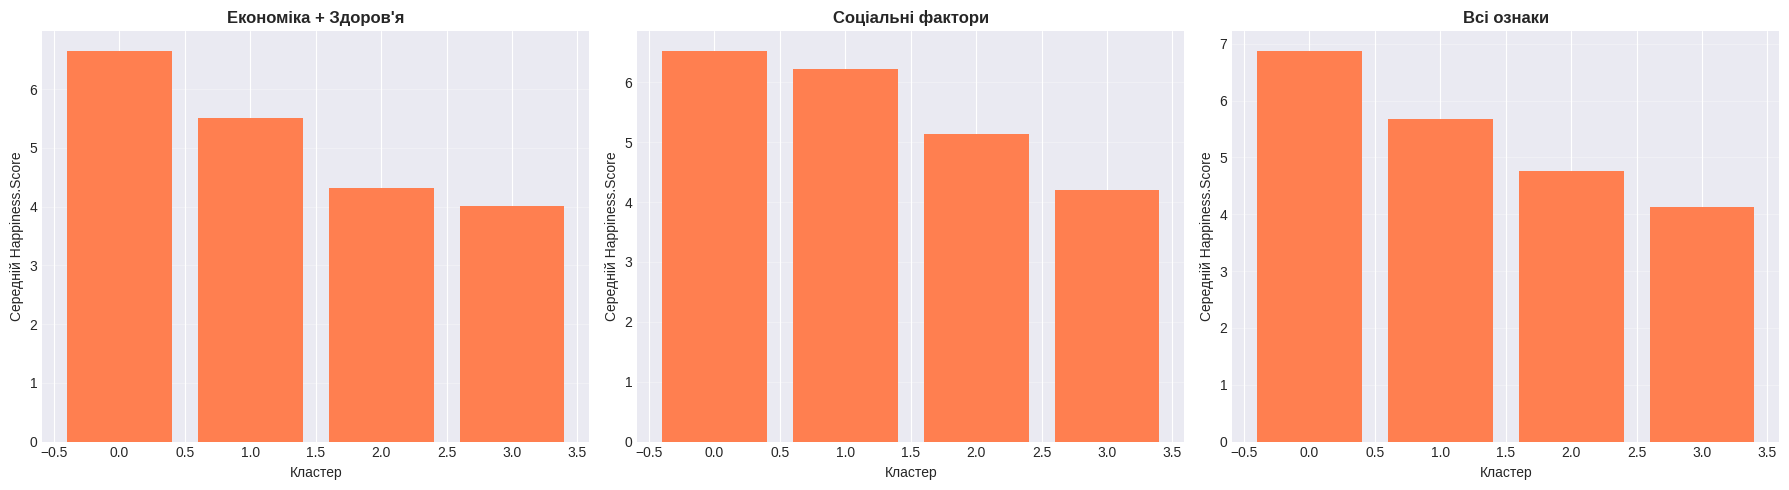

Висновок:
Різні набори ознак дають різні результати кластеризації.
Економічні показники створюють найчіткіше розділення.
Використання всіх ознак дає найбільш збалансований результат.


In [ ]:
# експеримент 1: тільки економічні показники
features_exp1 = ['Economy..GDP.per.Capita.', 'Health..Life.Expectancy.']
scaled_exp1 = data_scale(df[features_exp1], scaler_type='std')
labels_exp1, _ = apply_gmm(scaled_exp1, 4)
df['Cluster_Exp1'] = labels_exp1

print("Експеримент 1 (Економіка + Здоров'я):")
print(df.groupby('Cluster_Exp1')['Happiness.Score'].mean().sort_values(ascending=False))

# експеримент 2: соціальні фактори
features_exp2 = ['Family', 'Freedom', 'Trust..Government.Corruption.']
scaled_exp2 = data_scale(df[features_exp2], scaler_type='std')
labels_exp2, _ = apply_gmm(scaled_exp2, 4)
df['Cluster_Exp2'] = labels_exp2

print("\nЕксперимент 2 (Сім'я + Свобода + Довіра):")
print(df.groupby('Cluster_Exp2')['Happiness.Score'].mean().sort_values(ascending=False))

# експеримент 3: всі ознаки
features_exp3 = features_for_scaling
scaled_exp3 = data_scale(df[features_exp3], scaler_type='std')
labels_exp3, _ = apply_gmm(scaled_exp3, 4)
df['Cluster_Exp3'] = labels_exp3

print("\nЕксперимент 3 (Всі ознаки):")
print(df.groupby('Cluster_Exp3')['Happiness.Score'].mean().sort_values(ascending=False))

# візуалізація порівняння
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

experiments = [('Cluster_Exp1', 'Економіка + Здоров\'я'),
               ('Cluster_Exp2', 'Соціальні фактори'),
               ('Cluster_Exp3', 'Всі ознаки')]

for idx, (cluster_col, title) in enumerate(experiments):
    cluster_means = df.groupby(cluster_col)['Happiness.Score'].mean().sort_values(ascending=False)
    axes[idx].bar(range(len(cluster_means)), cluster_means.values, color='coral')
    axes[idx].set_title(title, fontsize=12, weight='bold')
    axes[idx].set_xlabel('Кластер')
    axes[idx].set_ylabel('Середній Happiness.Score')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Висновок:")
print("Різні набори ознак дають різні результати кластеризації.")
print("Економічні показники створюють найчіткіше розділення.")
print("Використання всіх ознак дає найбільш збалансований результат.")

### Крок 14: Загальні висновки

In [ ]:
print("="*70)
print("ЗАГАЛЬНІ ВИСНОВКИ")
print("="*70)

print("Якість даних:")
print("   Датасет містить 155 країн з повними даними про щастя.")
print("   Всі показники мають нормальний або близький до нормального розподіл.")

print("Кореляційний аналіз:")
print("   Найсильніший вплив на щастя мають: економіка (GDP), сім'я та здоров'я.")
print("   Generosity показує найменший зв'язок з іншими факторами.")

print("Результати кластеризації GMM:")
print("   Модель успішно виділила 4 групи країн за рівнем щастя:")
print("   • Високий рівень щастя (Скандинавія, Західна Європа)")
print("   • Вище середнього (Північна Америка, частина Латинської Америки)")
print("   • Середній рівень (Азія, Східна Європа)")
print("   • Низький рівень (Африка, деякі азійські країни)")

print("Вплив вибору ознак:")
print("   Економічні показники - найвагоміші для кластеризації.")
print("   Соціальні фактори додають нюанси розподілу.")
print("   Комбінація всіх ознак дає найкраще розуміння структури даних.")

print("Відповідність реальності:")
print("   GMM кластеризація добре відповідає реальному географічному")
print("   та економічному розподілу країн за рівнем щастя.")
print("   Результати узгоджуються з оригінальним Happiness.Score.")

print("Практичне застосування:")
print("   Модель може використовуватись для:")
print("   - Порівняння країн з подібними характеристиками")
print("   - Виявлення факторів для покращення рівня щастя")
print("   - Прогнозування змін у майбутньому")

print("\n" + "="*70)
print("Завдання виконано!")
print("="*70)

ЗАГАЛЬНІ ВИСНОВКИ
Якість даних:
   Датасет містить 155 країн з повними даними про щастя.
   Всі показники мають нормальний або близький до нормального розподіл.
Кореляційний аналіз:
   Найсильніший вплив на щастя мають: економіка (GDP), сім'я та здоров'я.
   Generosity показує найменший зв'язок з іншими факторами.
Результати кластеризації GMM:
   Модель успішно виділила 4 групи країн за рівнем щастя:
   • Високий рівень щастя (Скандинавія, Західна Європа)
   • Вище середнього (Північна Америка, частина Латинської Америки)
   • Середній рівень (Азія, Східна Європа)
   • Низький рівень (Африка, деякі азійські країни)
Вплив вибору ознак:
   Економічні показники - найвагоміші для кластеризації.
   Соціальні фактори додають нюанси розподілу.
   Комбінація всіх ознак дає найкраще розуміння структури даних.
Відповідність реальності:
   GMM кластеризація добре відповідає реальному географічному
   та економічному розподілу країн за рівнем щастя.
   Результати узгоджуються з оригінальним Happin